<a href="https://colab.research.google.com/github/ingdia/alu-advanced-linear-algebra-PCA./blob/main/PCA_Formative_1%5BGroupe32_cohort1%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

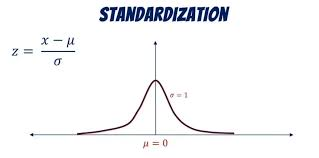


In [ ]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load your custom African malaria dataset
df = pd.read_csv('DatasetAfricaMalaria.csv')

country_name = df['Country Name'].values

cols_to_keep = [
    'Incidence of malaria (per 1,000 population at risk)',
    'Malaria cases reported',
    'Rural population (% of total population)',
    'Rural population growth (annual %)',
    'Urban population (% of total population)',
    'Urban population growth (annual %)',
    'People using at least basic drinking water services (% of population)',
    'People using at least basic drinking water services, rural (% of rural population)',
    'People using at least basic drinking water services, urban (% of urban population)',
    'People using at least basic sanitation services (% of population)',
    'People using at least basic sanitation services, rural (% of rural population)',
    'People using at least basic sanitation services, urban  (% of urban population)'
    ]

df_clean = df[cols_to_keep].copy()

print("Shape:", df_clean.shape)
print("\nNaN % per column:")
print((df_clean.isna().sum() / len(df_clean) * 100).round(1))

df_clean = df_clean.fillna(df_clean.mean())
print("NaN count after imputation:", df_clean.isna().sum().sum())

X = df_clean.to_numpy()
print("Data matrix X loaded successfully! Shape:", X.shape)

col_means = np.mean(X, axis=0)
col_stds = np.std(X, axis=0)
col_stds[col_stds == 0] = 1.0

standardized_data = (X - col_means) / col_stds
print("Standardized shape:", standardized_data.shape)

print("\nMeans (should all be ~0):")
print(np.round(np.mean(standardized_data, axis=0), 4))

print("\nStd devs (should all be ~1):")
print(np.round(np.std(standardized_data, axis=0), 4))

print("\nFirst 5 rows:")
print(np.round(standardized_data[:5], 4))


Shape: (594, 12)

NaN % per column:
Incidence of malaria (per 1,000 population at risk)                                   7.4
Malaria cases reported                                                                7.4
Rural population (% of total population)                                              1.0
Rural population growth (annual %)                                                    1.0
Urban population (% of total population)                                              1.0
Urban population growth (annual %)                                                    1.0
People using at least basic drinking water services (% of population)                 1.0
People using at least basic drinking water services, rural (% of rural population)    4.7
People using at least basic drinking water services, urban (% of urban population)    4.7
People using at least basic sanitation services (% of population)                     1.0
People using at least basic sanitation services, rural (% of rur

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [ ]:
# Step 3: Calculate the Covariance Matrix
n_samples = standardized_data.shape[0]

# Formula: (Z^T * Z) / (n - 1) using pure NumPy matrix dot multiplication
cov_matrix = np.dot(standardized_data.T, standardized_data) / (n_samples - 1)
cov_matrix

array([[ 1.00168634,  0.28899539,  0.24544679,  0.38713922, -0.24545029,
         0.30961969, -0.36891253, -0.31348426, -0.39901543, -0.44098387,
        -0.37580098, -0.42594845],
       [ 0.28899539,  1.00168634,  0.21333737,  0.24023442, -0.21334606,
         0.25243049, -0.23244903, -0.18060952, -0.16759034, -0.17510584,
        -0.11434487, -0.20858905],
       [ 0.24544679,  0.21333737,  1.00168634,  0.6527522 , -1.00168633,
         0.22866807, -0.6262459 , -0.27439309, -0.26699267, -0.51359092,
        -0.26661431, -0.44049159],
       [ 0.38713922,  0.24023442,  0.6527522 ,  1.00168634, -0.6527523 ,
         0.33022238, -0.59193849, -0.40540788, -0.39962352, -0.51458269,
        -0.38221811, -0.441068  ],
       [-0.24545029, -0.21334606, -1.00168633, -0.6527523 ,  1.00168634,
        -0.22867207,  0.62624836,  0.27439493,  0.26699783,  0.51359345,
         0.26661723,  0.4404946 ],
       [ 0.30961969,  0.25243049,  0.22866807,  0.33022238, -0.22867207,
         1.00168634, -

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

We compute a covariance matrix to help identify the linear relationships and variance scales among the 12 features selected. If after computing the covariance matrix, we realise that certain features have high correlations, this is redundant data that PCA can compress further while still preserving the data's integrity. The second reason is that the covariance matrix is the acutal input that PCA needs to compute the principal component values because the eigenvalues and eigenvectors are derived from this matrix.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvalues, eigenvectors

(array([6.22773990e+00, 1.71035174e+00, 1.06016939e+00, 7.86875115e-01,
        6.94145848e-01, 6.16741132e-01, 3.97794808e-01, 2.39871035e-01,
        1.68529550e-01, 1.09763808e-01, 8.25375781e-03, 1.07085738e-08]),
 array([[-2.14325736e-01,  5.01910189e-02,  4.60076582e-01,
          4.73600325e-01, -5.52130148e-01, -3.13874725e-01,
          2.71783876e-01, -1.85518238e-01,  2.45014333e-02,
         -5.12203265e-02, -2.65562438e-02,  2.98256056e-07],
        [-1.26872920e-01, -1.09249606e-01,  7.89357412e-01,
         -1.65219560e-01,  2.33068533e-01,  5.07738166e-01,
         -5.54544980e-02,  1.41132261e-02, -7.46265352e-02,
         -2.31897822e-02,  9.21428714e-03,  6.03757004e-06],
        [-2.66606885e-01, -5.45580233e-01, -1.30793410e-01,
         -1.50390844e-02,  4.11954817e-02,  2.40317547e-02,
          2.50139429e-01,  4.70382049e-02,  8.34234625e-02,
         -1.76226374e-01,  9.41306729e-02,  7.07104784e-01],
        [-2.78568705e-01, -3.12458467e-01,  4.74583448e-02,

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sorts indices from highest to lowest
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# Calculate Explained Variance and Cumulative Explained Variance Percentages
total_variance = np.sum(sorted_eigenvalues)
explained_variance_ratio = sorted_eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Sorted Eigenvalues:\n", sorted_eigenvalues)
print("\nCumulative Explained Variance Ratio:\n", cumulative_variance)

Sorted Eigenvalues:
 [6.22773990e+00 1.71035174e+00 1.06016939e+00 7.86875115e-01
 6.94145848e-01 6.16741132e-01 3.97794808e-01 2.39871035e-01
 1.68529550e-01 1.09763808e-01 8.25375781e-03 1.07085738e-08]

Cumulative Explained Variance Ratio:
 [0.51810462 0.66039399 0.7485927  0.81405524 0.87180334 0.92311191
 0.95620567 0.97616127 0.99018176 0.99931334 1.         1.        ]


Explained variance measures the specific proportion of the dataset's total mathematical variance carried by each principal component, mapping directly to the magnitude of its sorted eigenvalue. It serves as a diagnostic tool to evaluate how much informational fidelity is retained during data compression. By computing cumulative variance, a threshold can be dynamically set (e.g., keeping components that explain 85% of total variance) to safely filter out weak, noisy dimensions.


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components

# Dynamically select number of components that explain at least 85% variance
threshold = 0.85
num_components = int(np.argmax(cumulative_variance >= threshold) + 1)

print(f"Number of components selected: {num_components}")
print(f"Cumulative variance explained: {cumulative_variance[num_components - 1] * 100:.2f}%")

# Build the projection matrix W using the top-k eigenvectors
# sorted_eigenvectors columns are already sorted — just slice the first num_components
W = sorted_eigenvectors[:, :num_components]          # shape: (12, 5)

# Project: multiply standardized data by W
reduced_data = np.dot(standardized_data, W)

print("Projection matrix W shape:", W.shape)
print("\nFirst 5 rows of reduced data:")
print(np.round(reduced_data[:5], 4))

Number of components selected: 5
Cumulative variance explained: 87.18%
Projection matrix W shape: (12, 5)

First 5 rows of reduced data:
[[ 5.0219 -0.1329  0.2361 -0.5924  0.2498]
 [-1.6826  2.0072  0.5579 -1.495  -0.9973]
 [-1.9639  0.6993  0.1243  1.6722 -0.7843]
 [ 2.8393  0.9771 -0.1916 -0.7575  1.477 ]
 [-2.8493 -0.2989  0.2638  0.5075 -0.5424]]


### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data

print(f"Original data shape : {standardized_data.shape}")   # (594, 12)
print(f"Reduced data shape  : {reduced_data.shape}")        # (594, 5)
print(f"Dimensions removed  : {standardized_data.shape[1] - reduced_data.shape[1]}")

print("\nFirst 5 rows of reduced data:")
print(np.round(reduced_data[:5], 4))

Original data shape : (594, 12)
Reduced data shape  : (594, 5)
Dimensions removed  : 7

First 5 rows of reduced data:
[[ 5.0219 -0.1329  0.2361 -0.5924  0.2498]
 [-1.6826  2.0072  0.5579 -1.495  -0.9973]
 [-1.9639  0.6993  0.1243  1.6722 -0.7843]
 [ 2.8393  0.9771 -0.1916 -0.7575  1.477 ]
 [-2.8493 -0.2989  0.2638  0.5075 -0.5424]]


### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

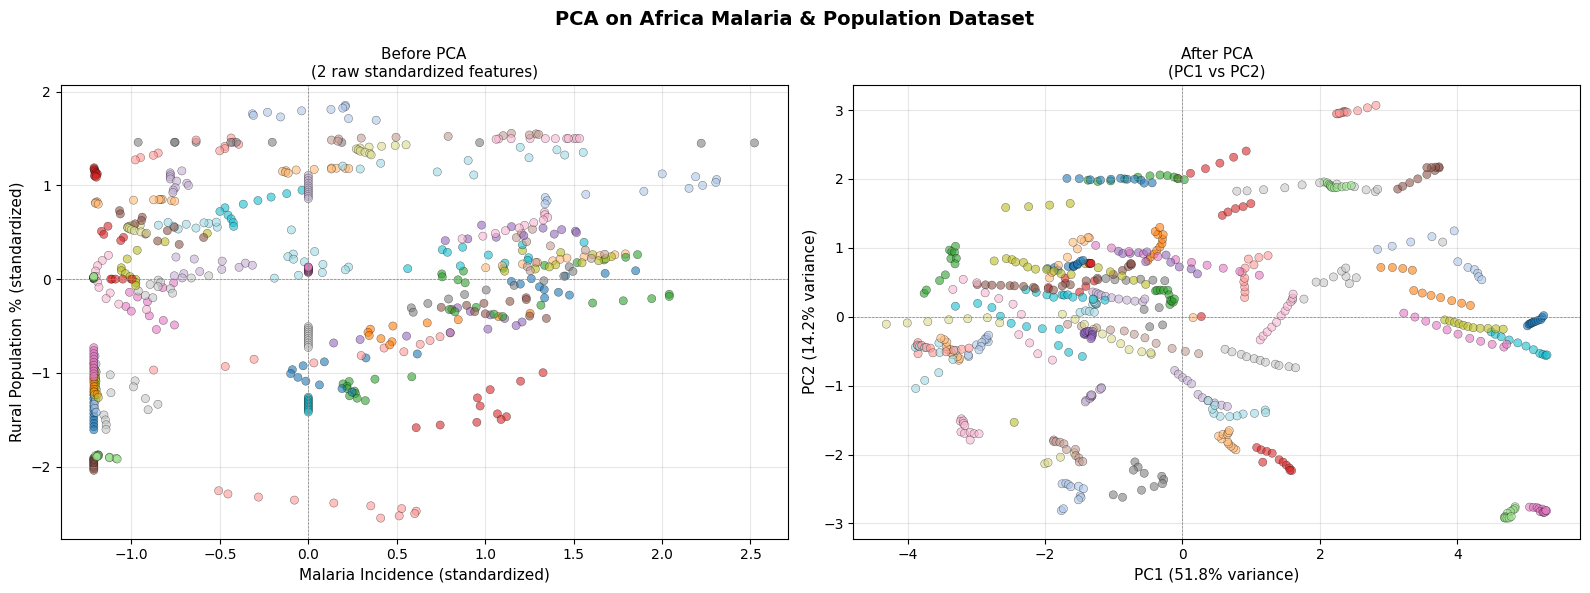

In [ ]:
# Step 8: Visualize Before and After PCA

# Encode country names as integers for colouring
unique_countries  = np.unique(country_name)
country_index_map = {name: idx for idx, name in enumerate(unique_countries)}
country_encoded   = np.array([country_index_map[c] for c in country_name])
colors            = plt.cm.tab20(country_encoded / max(country_encoded.max(), 1))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA on Africa Malaria & Population Dataset', fontsize=14, fontweight='bold')

# LEFT: Before PCA — col 0 (malaria incidence) vs col 2 (rural population %)
axes[0].scatter(
    standardized_data[:, 0],
    standardized_data[:, 2],
    c=colors, alpha=0.6, edgecolors='k', linewidths=0.3, s=35
)
axes[0].set_xlabel('Malaria Incidence (standardized)', fontsize=11)
axes[0].set_ylabel('Rural Population % (standardized)', fontsize=11)
axes[0].set_title('Before PCA\n(2 raw standardized features)', fontsize=11)
axes[0].axhline(0, color='grey', linewidth=0.5, linestyle='--')
axes[0].axvline(0, color='grey', linewidth=0.5, linestyle='--')
axes[0].grid(True, alpha=0.3)

# RIGHT: After PCA — PC1 vs PC2
axes[1].scatter(
    reduced_data[:, 0],
    reduced_data[:, 1],
    c=colors, alpha=0.6, edgecolors='k', linewidths=0.3, s=35
)
axes[1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance)', fontsize=11)
axes[1].set_title('After PCA\n(PC1 vs PC2)', fontsize=11)
axes[1].axhline(0, color='grey', linewidth=0.5, linestyle='--')
axes[1].axvline(0, color='grey', linewidth=0.5, linestyle='--')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA

The before PCA plot on the left shows the relationship between just two features, Rural population vs Malaria Incidence, out of the total 12 features, so the points are loosely scattered with no strong detectable pattern. After PCA, PC1 alone showes about 51.8% total variance with PC2 having a further variance of 14.2% which highlights the strong correlation across a combined profile of all 12 features selected from the dataset.

2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

A total of 5 components were selected because that is the minimum needed to exceed 85% cummulative explained variance reaching. The 5 components selected exceeded the 85% treshold required giving a cummulative explained variance of 87.18%. The tradeoff is that the remaining 12.82% of variance which was spread across the 7 other dropped components are permanently lost. Choosing fewer components(e.g. 3 at like 70%) would mean that it would compress more making it easier to compute but at the expense of a detailed analysis. The opposite is true for selecting more components(e.g. 7 at like 97%)

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

This dataset highlight 2 major ideas i.e. how developed a country's water/sanitation sytem is and how fast its cities and rural areas are growing. As explained earlier, compressing 12 features down to 5 maintains the big picture differences between countries but you still end up losing some finer, more nuanced details about rural vs urban sanitation gaps which is a critical signal for identifying countries where urban infrastructure lags behind urban population growth. This key distinction is collapesed into the PC1 axis, which means countries with very different urban sanitation profiles but similar overall avarages might appear closer in the reduced space.
